## Customer Sales Analysis Project

The objective of this project is to analyze a retail company's sales dataset to gain actionable insights into revenue trends, top-performing products, key customers, and profit distribution across regions. The analysis will help in identifying patterns, seasonal trends, and business opportunities for improving sales and optimizing strategy.

#### Important Libraries

#### Load Dataset

In [126]:
import pandas as pd

df = pd.read_csv("Practice_Projects/Sample - Superstore.csv", encoding='latin1')
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

## Analyzing ,filtering and Cleaning the data

In [127]:
# Display first 5 rows of table

# first_five_rows = df.head()
# print(first_five_rows)

# Checks how many null data are there.
count_null = df.isnull().sum()
print(f"Count Null Values : \n{count_null}\n")

# Checked Duplicates data
count_duplicate = df.duplicated().sum()
print(f"Count Duplicates : {count_duplicate}\n")

# Default order and ship date wa showing object thats not true, so converted to datetime64
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# For performance, we can optimize some columns as below:
# In our dataset, Region and segments will have only a few values like east, west, south, north in region and  consumer , corporate in segment.Each value stored as full string → more memory
# Instead of storing these as full strings again and again of region, pandas can store them more efficiently as categories (labels + codes), so we took region and segment as category.

df['Category'] = df['Category'].astype('category')
df['Region'] = df['Region'].astype('category')
df['Segment'] = df['Segment'].astype('category')


# Table info
data_info = df.info()
print(f"Data Info : \n{data_info}\n")

# List of object datatype from data
objects_list = df.select_dtypes(include='object').columns
print(f"List of objects data type : \n{objects_list}\n")



Count Null Values : 
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Count Duplicates : 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-

### Meaningfull insights from data

### Total Sales

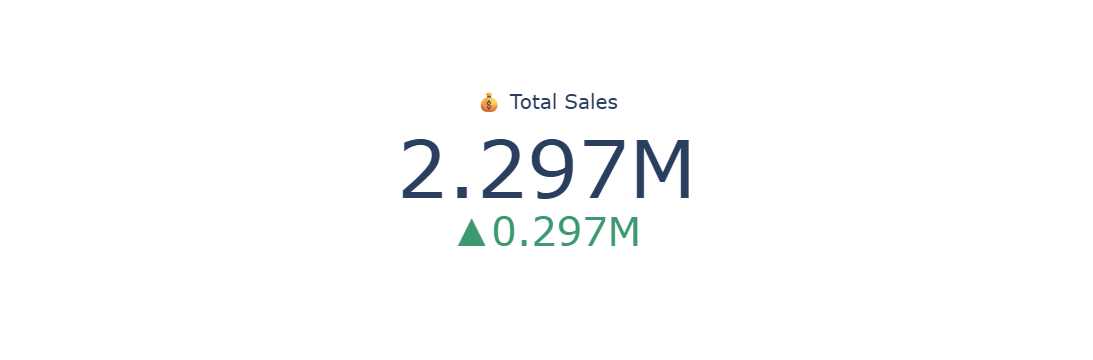

In [128]:
import plotly.graph_objects as go
from IPython.display import display, HTML

def plot_total_sales(df, reference=2000000):
    total_sales = df["Sales"].sum()
    
    # Plot Indicator
    fig = go.Figure(go.Indicator(
        mode="number+delta",
        value=total_sales,
        delta={"reference": reference},  # previous sales
        title={"text": "💰 Total Sales"}
    ))
    fig.show()
    
    # Generate dynamic insight
    trend = "positive" if total_sales > reference else "negative"
    
    # Display bold & bigger font in Jupyter
    display(HTML(f"<p style='font-size:16px; font-weight:400;'>"
                 f"📌 Total sales for the period are <b>₹{total_sales:.2f}</b>. "
                 f"Compared to reference sales of ₹{reference}, the company shows a <b>{trend}</b> trend."
                 f"</p>"))

# Call the function
plot_total_sales(df)

### Category Wise Sales

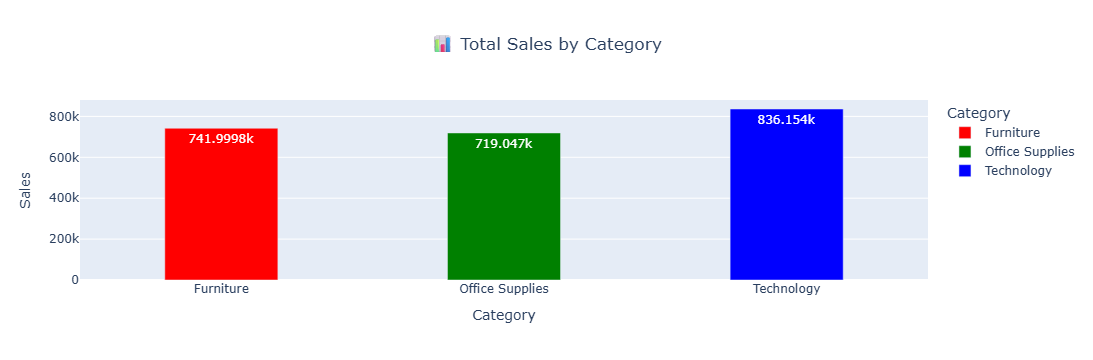

In [129]:
import plotly.express as px
from IPython.display import display, HTML

# Aggregate sales by category
sales_data = df.groupby('Category', observed=True)['Sales'].sum().reset_index()

# Plot bar chart
fig = px.bar(
    sales_data,
    x='Category',
    y='Sales',
    color='Category',
    title='📊 Total Sales by Category',
    text_auto=True,
    color_discrete_map={
        "Furniture": "red",
        "Technology": "blue",
        "Office Supplies": "green"
    }
)
fig.update_traces(width=0.4)
fig.update_layout(
    xaxis_title="Category",
    yaxis_title="Sales",
    title_x=0.5
)

fig.show()

# --- Dynamic Insight (bold and bigger font) ---
top_category = sales_data.loc[sales_data['Sales'].idxmax(), 'Category']
top_sales = sales_data['Sales'].max()

display(HTML(f"<p style='font-size:16px; font-weight:400;'>"
             f"📌 Top revenue-generating category is <b>{top_category}</b> "
             f"with total sales of <b>₹{top_sales:.2f}</b>."
             f"</p>"))

### Top 10 Product by Sales

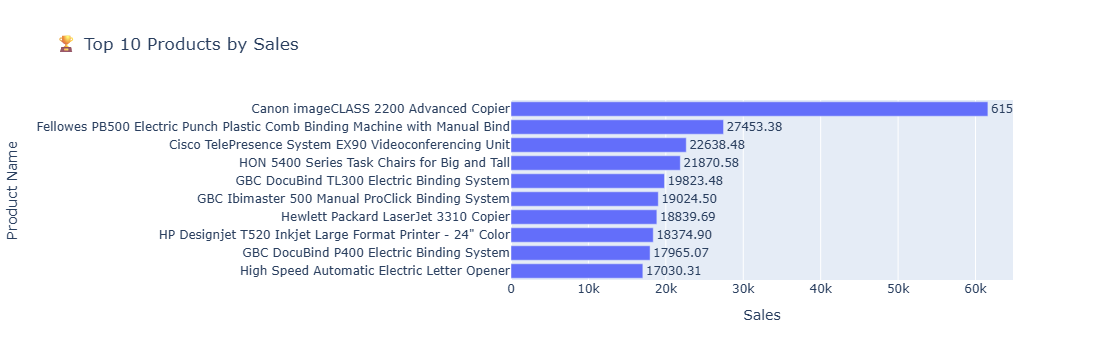

In [130]:
import plotly.express as px
from IPython.display import display, HTML

# Top 10 products
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products = top_products.sort_values()  # for horizontal chart
top_products_df = top_products.reset_index()
top_products_df.columns = ['Product Name', 'Sales']

# Plot horizontal bar chart
fig = px.bar(
    top_products_df,
    x='Sales',
    y='Product Name',
    orientation='h',
    title='🏆 Top 10 Products by Sales',
    text='Sales'
)
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig.update_layout(yaxis={'categoryorder':'total ascending'})  # top product on top
fig.show()

# --- Dynamic Insight ---
top_product_name = top_products_df.loc[top_products_df['Sales'].idxmax(), 'Product Name']
top_product_sales = top_products_df['Sales'].max()

display(HTML(f"<p style='font-size:16px; font-weight:400;'>"
             f"📌 The highest-selling product is <b>{top_product_name}</b> "
             f"with total sales of <b>₹{top_product_sales:.2f}</b>."
             f"</p>"))

### Yearly Sales Revenue

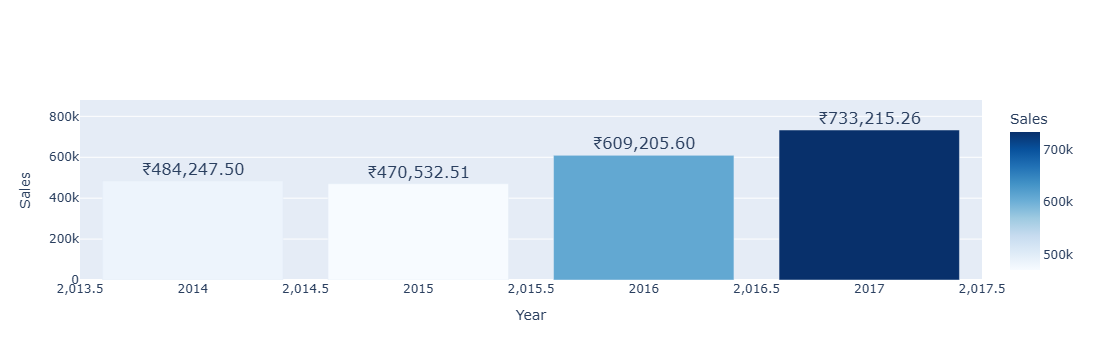

In [131]:
import plotly.express as px
from IPython.display import display, HTML

# Extract year
df['Year'] = df['Order Date'].dt.year

# Aggregate yearly sales
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()

# Extra top padding for text
y_axis_max = yearly_sales['Sales'].max() * 1.20 

# Prepare hover text dynamically
yearly_sales['hover_text'] = yearly_sales.apply(lambda row: f"Year: {row['Year']}<br>Sales: ₹{row['Sales']:,.2f}", axis=1)

# Plot chart
fig = px.bar(
    yearly_sales,
    x='Year',
    y='Sales',
    color='Sales',  # color by sales value
    color_continuous_scale='Blues',
    text=yearly_sales['Sales'].apply(lambda x: f"₹{x:,.2f}"),  # formatted text on bars
    hover_data={'Sales': False, 'hover_text': True}  # show only custom hover text
)

# Make text appear outside bars
fig.update_traces(textposition='outside', textfont_size=16, hovertemplate='%{customdata[0]}')

# Update layout
fig.update_layout(
    yaxis=dict(title='Sales', range=[0, y_axis_max], automargin=True),
    xaxis_title='Year',
    margin=dict(t=100)
)

fig.show()

# --- Dynamic Insight ---
top_year = yearly_sales.loc[yearly_sales['Sales'].idxmax(), 'Year']
top_year_sales = yearly_sales['Sales'].max()

display(HTML(f"<p style='font-size:16px; font-weight:600;'>"
             f"📌 The year with the highest sales is <b>{top_year}</b> "
             f"with total sales of <b>₹{top_year_sales:,.2f}</b>."
             f"</p>"))

### Monthly sales by Year and Top month of sale

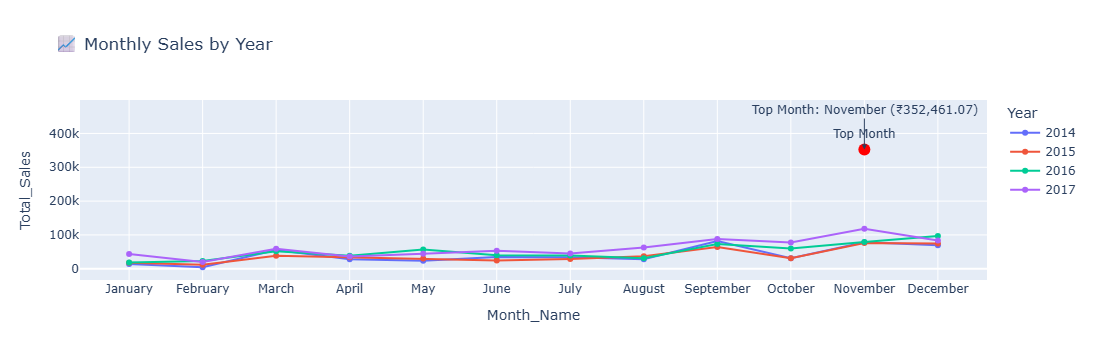

In [132]:
import plotly.express as px
from IPython.display import display, HTML
import calendar

# Extract Month and Year
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year
df['Month_Name'] = df['Month'].apply(lambda x: calendar.month_name[x])

# Aggregate monthly sales
monthly_sales = df.groupby(["Year","Month","Month_Name"])["Sales"].sum().reset_index()
monthly_sales.columns = ['Year', 'Month', 'Month_Name', 'Total_Sales']

# Find overall top month
monthly_total = monthly_sales.groupby('Month')['Total_Sales'].sum()
top_month = monthly_total.idxmax()
top_month_sales = monthly_total.max()
top_month_name = calendar.month_name[top_month]

# Plot line chart
fig = px.line(
    monthly_sales,
    x='Month_Name',
    y='Total_Sales',
    color='Year',
    markers=True,
    title='📈 Monthly Sales by Year'
)

# Highlight top month with annotation
fig.add_annotation(
    x=top_month_name,
    y=top_month_sales,
    text=f"Top Month: {top_month_name} (₹{top_month_sales:,.2f})",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-40
)

# Add red marker for top month
fig.add_scatter(
    x=[top_month_name],
    y=[top_month_sales],
    mode='markers+text',
    marker=dict(color='red', size=12),
    text=[f"Top Month"],
    textposition="top center",
    showlegend=False
)

fig.show()

# --- Dynamic Insight ---
display(HTML(f"<p style='font-size:16px; font-weight:600;'>"
             f"📌 The top revenue-generating month overall is <b>{top_month_name}</b> "
             f"with total sales of <b>₹{top_month_sales:,.2f}</b>."
             f"</p>"))

### Profit By Region

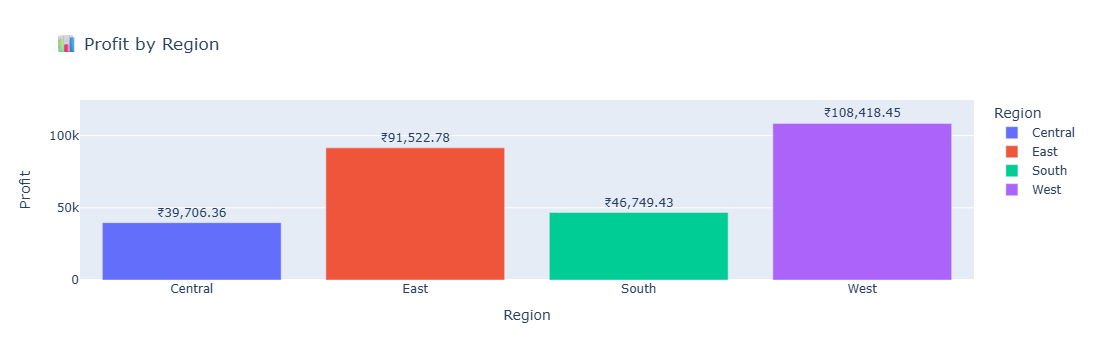

In [133]:
import plotly.express as px
from IPython.display import display, HTML

# Aggregate profit by region
profit_region = df.groupby("Region", observed=True)["Profit"].sum().reset_index()

# Find top region
top_region = profit_region.loc[profit_region['Profit'].idxmax(), 'Region']
top_profit = profit_region['Profit'].max()
y_axis_max = profit_region['Profit'].max() * 1.15

# Custom hover text
profit_region['hover_text'] = profit_region['Profit'].apply(lambda x: f"Profit: ₹{x:,.2f}")

# Plot chart
fig = px.bar(
    profit_region,
    x='Region',
    y='Profit',
    text=profit_region['Profit'].apply(lambda x: f"₹{x:,.2f}"),
    color='Region',
    title='📊 Profit by Region',
    hover_data={'Profit': False, 'hover_text': True}  # only show hover_text
)

fig.update_traces(
    textposition='outside',
    textfont_size=12,
    hovertemplate='%{customdata[0]}'  # show only hover_text
)

fig.update_layout(
    yaxis=dict(title='Profit', range=[0, y_axis_max], automargin=True),
    xaxis_title='Region',
    margin=dict(t=100)
)

fig.show()

# Dynamic Insight
display(HTML(f"<p style='font-size:16px; font-weight:600;'>"
             f"📌 The region with the highest profit is <b>{top_region}</b> "
             f"with a total profit of <b>₹{top_profit:,.2f}</b>."
             f"</p>"))

### Top 10 Customers Sales data

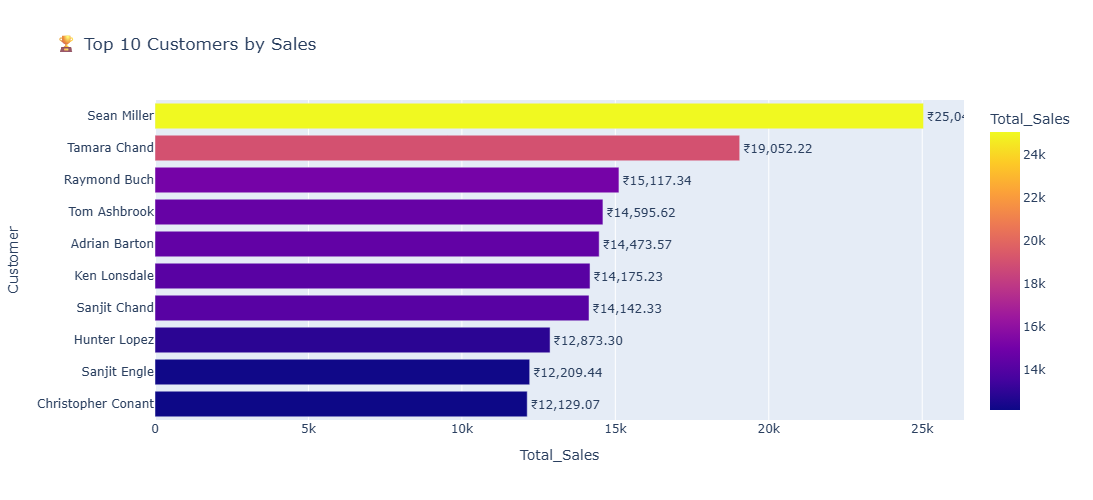

In [134]:
import plotly.express as px
from IPython.display import display, HTML

# --- Aggregate top 10 customers dynamically ---
top_customers_df = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)
top_customers_df.columns = ['Customer', 'Total_Sales']

# --- Prepare text for bars and hover ---
top_customers_df['text_label'] = top_customers_df['Total_Sales'].apply(lambda x: f"₹{x:,.2f}")
top_customers_df['hover_text'] = top_customers_df['Total_Sales'].apply(lambda x: f"Sales: ₹{x:,.2f}")

# --- Identify top customer dynamically ---
top_customer = top_customers_df.loc[top_customers_df['Total_Sales'].idxmax(), 'Customer']
top_sales = top_customers_df['Total_Sales'].max()

# --- Create horizontal bar chart ---
fig = px.bar(
    top_customers_df,
    x='Total_Sales',
    y='Customer',
    orientation='h',
    text='text_label',
    color='Total_Sales',
    hover_data={'Total_Sales': False, 'hover_text': True},
    title='🏆 Top 10 Customers by Sales',
    width=1000,
    height=500
)

# --- Update layout and trace ---
fig.update_traces(
    textposition='outside',
    textfont_size=12,
    hovertemplate='%{customdata[0]}'
)
fig.update_layout(
    yaxis={'categoryorder':'total ascending'},
    margin=dict(l=150, r=50, t=100)  # enough left margin for names
)

# --- Show chart ---
fig.show()

# --- Dynamic Insight ---
display(HTML(f"<p style='font-size:16px; font-weight:400;'>"
             f"📌 The top customer is <b>{top_customer}</b> "
             f"with total sales of <b>₹{top_sales:,.2f}</b>."
             f"</p>"))

## Exploratory Data Analysis (EDA)

### Total Sales
- **Chart:** Total Sales Indicator
- **Insight:** Total sales for the period are **₹2.297M**. Compared to reference sales of ₹2,000,000, the company shows a positive/negative trend. This is the baseline for further analysis.

### Total Sales by Category
- **Chart:** Bar chart of total sales per category
- **Insight:** **Technology** generates the highest sales, followed by Furniture and Office Supplies.

### Top 10 Products by Sales
- **Chart:** Horizontal bar chart of top 10 products
- **Insight:** Product **Canon imageCLASS 2200 Advanced Copier** leads the sales, showing which products drive revenue.

### Yearly Sales Report
- **Chart:** Bar chart of yearly sales
- **Insight:** Highest revenue recorded in 2017, showing growth trends.

### Monthly Sales by Year
- **Chart:** Line chart with top month highlighted
- **Insight:** Peak sales in **November**, showing seasonal trends for inventory and marketing planning.

### Profit by Region
- **Chart:** Bar chart of total profit by region
- **Insight:** **West** is the most profitable region. Other regions may need attention for better returns.

### Top 10 Customers by Sales
- **Chart:** Horizontal bar chart of top 10 customers
- **Insight:** **Seam Miller** is the highest contributor, emphasizing the importance of key clients.

### Key Takeaways:

- **Technology** is the highest revenue-generating category.
- Product **Canon imageCLASS 2200 Advanced Copier** is the top-selling product driving revenue.
- **2017** had the highest annual sales.
- **November** is the top-performing month overall.
- **West** is the most profitable region.
- **Sean Miller** drives a significant portion of sales.

### Conclusion:

This analysis provides actionable insights for inventory optimization, marketing strategies, and resource allocation. The findings help drive revenue growth and strategic business decisions.